In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math as m


## 2.2

### a

In [2]:
C = np.zeros((100,100))

for i in range(0,100):
    for j in range(0, 100):
        C[i][j] = min((i+1)/100,(j+1)/100)

C




array([[0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
       [0.01, 0.02, 0.02, ..., 0.02, 0.02, 0.02],
       [0.01, 0.02, 0.03, ..., 0.03, 0.03, 0.03],
       ...,
       [0.01, 0.02, 0.03, ..., 0.98, 0.98, 0.98],
       [0.01, 0.02, 0.03, ..., 0.98, 0.99, 0.99],
       [0.01, 0.02, 0.03, ..., 0.98, 0.99, 1.  ]], shape=(100, 100))

### b

In [3]:
A = np.linalg.cholesky(C)
A

array([[0.1, 0. , 0. , ..., 0. , 0. , 0. ],
       [0.1, 0.1, 0. , ..., 0. , 0. , 0. ],
       [0.1, 0.1, 0.1, ..., 0. , 0. , 0. ],
       ...,
       [0.1, 0.1, 0.1, ..., 0.1, 0. , 0. ],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0. ],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1]], shape=(100, 100))

### c

In [4]:
def GaussianSamples(N=100):
    return np.random.normal(loc=0,scale=1,size=N)

### d

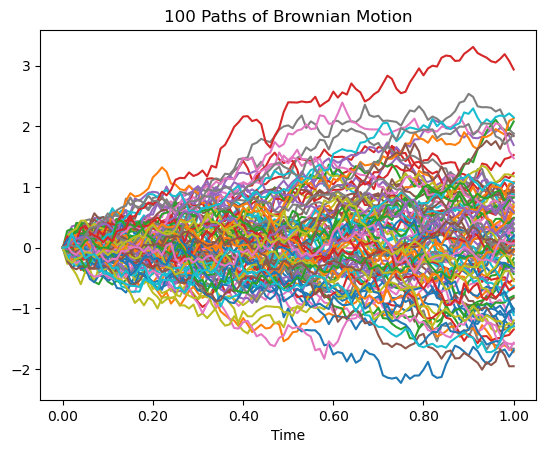

In [5]:
paths = []
for i in range(100):
    standard = GaussianSamples()
    Brownian = np.append(np.array([0]),A @ standard.T)
    paths.append(Brownian.tolist())

final = np.array(paths)
B_final = final
fig,ax = plt.subplots()
ax.plot(final.T)
ax.set_title("100 Paths of Brownian Motion")
ax.set_xlabel("Time")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/100:.2f}'))
plt.show()

## 2.3

### a

In [6]:
C = np.zeros((100,100))

for a in range(0,100):
    for b in range(0, 100):
        i = (a+1)/100
        j = (b+1)/100
        C[a][b] = (m.e ** (-2 * abs(j-i))) * (1- m.e **(-2*min(i,j))) / 2
    

print("C= ",C)
A= np.linalg.cholesky(C)


print("\nA=",A)


C=  [[0.00990066 0.00970462 0.00951245 ... 0.00142276 0.00139459 0.00136698]
 [0.00970462 0.01960528 0.01921707 ... 0.00287427 0.00281736 0.00276157]
 [0.00951245 0.01921707 0.02911773 ... 0.0043551  0.00426886 0.00418433]
 ...
 [0.00142276 0.00287427 0.0043551  ... 0.42957079 0.42106472 0.41272708]
 [0.00139459 0.00281736 0.00426886 ... 0.42106472 0.43096538 0.4224317 ]
 [0.00136698 0.00276157 0.00418433 ... 0.41272708 0.4224317  0.43233236]]

A= [[0.09950208 0.         0.         ... 0.         0.         0.        ]
 [0.0975318  0.10046307 0.         ... 0.         0.         0.        ]
 [0.09560054 0.09847376 0.10139619 ... 0.         0.         0.        ]
 ...
 [0.01429884 0.01472858 0.01516569 ... 0.13494698 0.         0.        ]
 [0.01401571 0.01443694 0.01486539 ... 0.13227486 0.13504926 0.        ]
 [0.01373818 0.01415107 0.01457103 ... 0.12965564 0.13237511 0.13514944]]


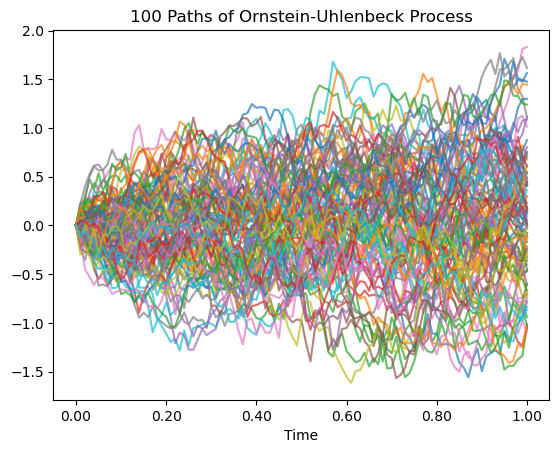

In [7]:
paths = []
for i in range(100):
    standard = GaussianSamples(100)
    OU = np.append(np.array([0]), A @ standard.T)
    paths.append(OU.tolist())

final = np.array(paths)
fig,ax = plt.subplots()
ax.plot(final.T,alpha = 0.7)
ax.set_title("100 Paths of Ornstein-Uhlenbeck Process")
ax.set_xlabel("Time")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/100:.2f}'))
plt.show()

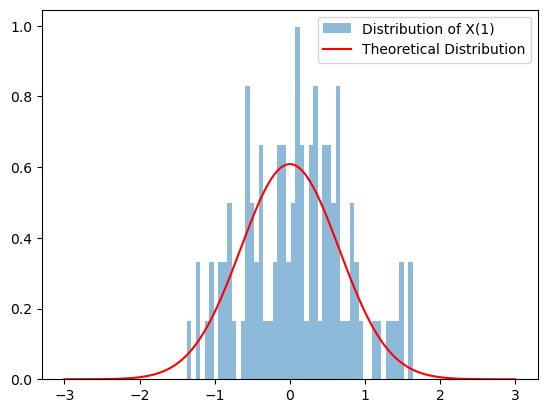

In [8]:
lines = np.linspace(-3,3,1000)
plt.hist(final.T[98], bins = 50, density=True,alpha = 0.5, label="Distribution of X(1)")
#plt.hist(np.random.normal(loc = 0, scale= m.sqrt(0.43233236), size = 10000), density=True, bins = 50, color = 'yellow', alpha = 0.5,label="N(0,1/2) Distribution")
plt.plot(lines, np.exp(-(lines**2)/(2*0.42957079))/m.sqrt(2*m.pi*0.42957079), color = 'red', label = "Theoretical Distribution")
plt.legend(loc = 'upper right')
plt.show()

### b

In [9]:
C = np.zeros((101,101))

for a in range(0,101):
    for b in range(0, 101):
        i = (a)/100
        j = (b)/100
        C[a][b] = (m.e ** (-2 * abs(j-i))) / 2

print("C= ",C)
A = np.linalg.cholesky(C)

print("\nA=",A)

C=  [[0.5        0.49009934 0.48039472 ... 0.07042921 0.06903462 0.06766764]
 [0.49009934 0.5        0.49009934 ... 0.07185197 0.07042921 0.06903462]
 [0.48039472 0.49009934 0.5        ... 0.07330348 0.07185197 0.07042921]
 ...
 [0.07042921 0.07185197 0.07330348 ... 0.5        0.49009934 0.48039472]
 [0.06903462 0.07042921 0.07185197 ... 0.49009934 0.5        0.49009934]
 [0.06766764 0.06903462 0.07042921 ... 0.48039472 0.49009934 0.5       ]]

A= [[0.70710678 0.         0.         ... 0.         0.         0.        ]
 [0.69310513 0.14001886 0.         ... 0.         0.         0.        ]
 [0.67938073 0.1372463  0.14001886 ... 0.         0.         0.        ]
 ...
 [0.09960194 0.02012126 0.02052774 ... 0.14001886 0.         0.        ]
 [0.09762969 0.01972284 0.02012126 ... 0.1372463  0.14001886 0.        ]
 [0.0956965  0.0193323  0.01972284 ... 0.13452864 0.1372463  0.14001886]]


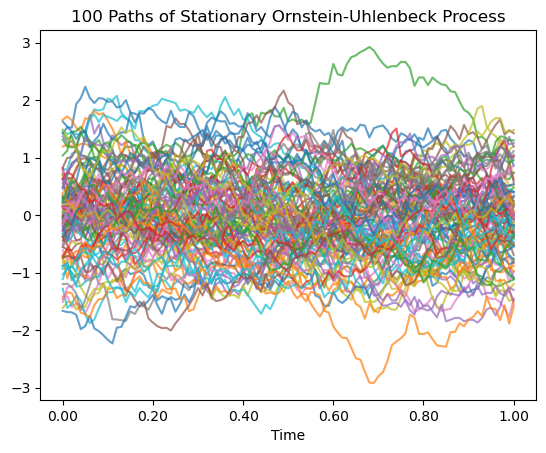

In [10]:
paths = []
for i in range(100):
    standard = GaussianSamples(101)
    SOU = A @ standard.T
    paths.append(SOU.tolist())

final = np.array(paths)
fig,ax = plt.subplots()
ax.plot(final.T,alpha = .7)
ax.set_title("100 Paths of Stationary Ornstein-Uhlenbeck Process")
ax.set_xlabel("Time")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/100:.2f}'))
plt.show()

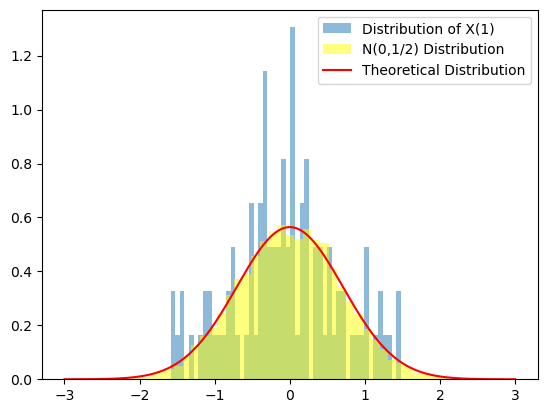

In [11]:
lines = np.linspace(-3,3,1000)
plt.hist(final.T[100], bins = 50, density=True,alpha = 0.5, label="Distribution of X(1)")
plt.hist(np.random.normal(loc = 0, scale= 1/m.sqrt(2), size = 10000), density=True, bins = 50, color = 'yellow', alpha = 0.5,label="N(0,1/2) Distribution")
plt.plot(lines, np.exp(-(lines**2) * 2/2)/m.sqrt(2*m.pi) * m.sqrt(2), color = 'red', label = "Theoretical Distribution")
plt.legend(loc = 'upper right')
plt.show()

## Bridge

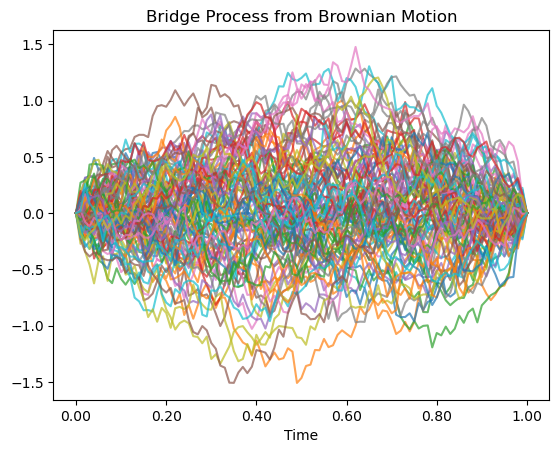

In [12]:
paths = []
for i in range(len(B_final)):
     bridge = np.array([])
     for j in range(len(B_final[0])):
          bridge = np.append(bridge,B_final[i][j]- (j/100)*B_final[i][-1])
     paths.append(bridge.tolist())

final = np.array(paths)
fig,ax = plt.subplots()
ax.plot(final.T,alpha = .7)
ax.set_title("Bridge Process from Brownian Motion")
ax.set_xlabel("Time")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/100:.2f}'))
plt.show()